In [1]:
# 1.3 Example for Exploration and Exploitation
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.random.seed(0)

C:\Users\DELL\anaconda3\envs\Torch280\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class EpsilonGreedyAgent:
    def __init__(self, num_actions, epsilon=0.1):
        self.num_actions = num_actions
        self.epsilon = epsilon
        self.action_values = np.zeros(num_actions)
        self.action_counts = np.zeros(num_actions)

    # Randomly choose an action for exploration
    # Choose the greedy action for exploitation
    def select_action(self):
        # YOUR CODE HERE
        if np.random.rand() < self.epsilon:
            # Randomly choose an action for exploration
            action = np.random.randint(self.num_actions)
        else:
            # Choose the greedy action for exploitation
            action = np.argmax(self.action_values)
        return action
        
    # Update action-counts increase 1 after each action 
    # Update action-value estimate using incremental upate rule
    # Qn+1 = Qn + (1/n)*(Rn - Qn)
    def update_value(self, action, reward):
        # YOUR CODE HERE
        self.action_counts[action] += 1
        # Update action-value estimate using incremental update rule
        self.action_values[action] += (1 / self.action_counts[action]) * (reward - self.action_values[action])

In [ ]:
agent = EpsilonGreedyAgent(num_actions=4)
print(agent.select_action())
print(agent.select_action())
print(agent.select_action())
print(agent.select_action())

0
0
0
0


In [ ]:
# Create a simple multi-armed bandit environment
class MultiArmedBandit:
    def __init__(self, num_arms):
        self.num_arms = num_arms
        self.true_action_values = np.random.normal(0, 1, num_arms)
    
    # Reward is sampled from a normal distribution with mean true 
    # action value and unit variance.
    # hint: use np.random.normal() to get random normal distribution 
    # value with input is action index
    def get_reward(self, action):     
        # YOUR CODE HERE
        return np.random.normal(self.true_action_values[action], 1)

In [ ]:
def runBanditProblem(num_arms, num_steps, epsilon):
    # Interaction loop
    bandit = MultiArmedBandit(num_arms)
    total_rewards = 0
    step_value = np.zeros(num_steps)
    agent = EpsilonGreedyAgent(num_arms, epsilon=epsilon)
    for step in range(num_steps):
        action = agent.select_action()
        reward = bandit.get_reward(action)
        agent.update_value(action, reward)
        total_rewards += reward
        step_value[step] = reward
    return total_rewards, step_value

In [ ]:
# testing run one time for bandit problem
total_reward, step_value = runBanditProblem(num_arms = 10, num_steps = 1000, epsilon=0.1)
print('Total reward: ', total_reward)

Total reward:  1700.619797963412



Training with epsilon = 0


  0%|          | 0/1000 [00:00<?, ?it/s]


Training with epsilon = 0.01


  0%|          | 0/1000 [00:00<?, ?it/s]


Training with epsilon = 0.1


  0%|          | 0/1000 [00:00<?, ?it/s]


Training with epsilon = 0.4


  0%|          | 0/1000 [00:00<?, ?it/s]

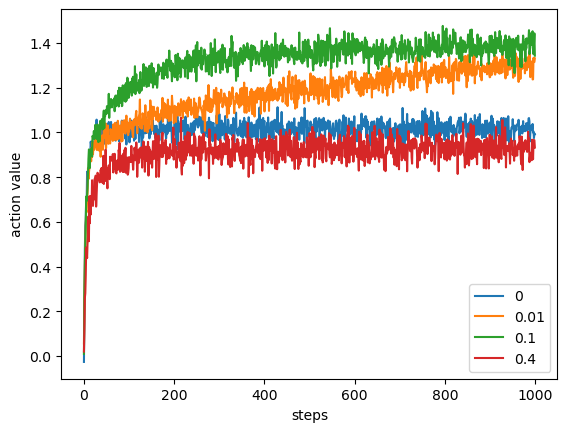

In [ ]:
# testing with difference epsilon
num_arms = 10
num_steps = 1000

epsilons = [0, 0.01, 0.1, 0.4]

for e in epsilons:   
    avg_step_value = np.zeros(num_steps)
    print(f"\nTraining with epsilon = {e}")
    progress_bar = tqdm(range(num_steps))
    for i in progress_bar:
        total_reward, step_value = runBanditProblem(num_arms = 10, num_steps = 1000, epsilon=e)
        avg_step_value += step_value
        
    avg_step_value /= num_steps
    plt.plot(avg_step_value, label = str(e))
    
plt.xlabel('steps')
plt.ylabel('action value')
plt.legend()
plt.show()